In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
# Configuration and paths
or_threshold_pheno = 0.99
or_threshold_anno = 0.95

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [15]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_genocode_251031.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
variant_class = "non_coding"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

# min_range = -500
# max_range = +0

anno = (
    anno
    # .filter(
        # filter_expression &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0) &
        #     (pl.col('consequence_splice_region_variant') == 0) &
        #     (pl.col('consequence_splice_donor_5th_base_variant') == 0) &
        #     (pl.col('consequence_splice_donor_region_variant') == 0) &
        #     (pl.col('consequence_splice_polypyrimidine_tract_variant') == 0)
        # ) &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0)
        #     # (pl.col('consequence_start_retained_variant') == 0) &
        #     # (pl.col('consequence_start_lost') == 0)
        # ) &
        
        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &
    # )
    .select(
        set(['id', 'region', 'ref', 'alt', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss', 'vep_gencode_non_coding'])
    )
    .with_columns(
        indel_length = (
            pl.col('alt').str.len_chars().cast(pl.Int64) - 
            pl.col('ref').str.len_chars().cast(pl.Int64)
        ).abs(),
        indel_type = pl.when(
            (pl.col('alt').str.len_chars() > pl.col('ref').str.len_chars())
        )
        .then(pl.lit('insertion'))
        .otherwise(
            pl.when(
                (pl.col('alt').str.len_chars() < pl.col('ref').str.len_chars())
            )
            .then(pl.lit('deletion'))
            .otherwise(pl.lit('SNP'))
        )
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

# anno = anno.filter(
#     pl.col('vep_gencode_non_coding') == True
# )

anno

dist_to_tss,gene_length,alt,ref,vep_gencode_non_coding,TSS,id,gene_name,region,Strand,indel_length,indel_type
i64,i64,str,str,bool,i64,str,str,str,cat,i64,str
165367,235427,"""G""","""T""",true,169362534,"""chr2:169197167:T:G""","""LRP2""","""ENSG00000081479""","""-""",0,"""SNP"""
158242,235427,"""T""","""A""",true,169362534,"""chr2:169204292:A:T""","""LRP2""","""ENSG00000081479""","""-""",0,"""SNP"""
793,115828,"""T""","""C""",true,169031324,"""chr2:169030531:C:T""","""ABCB11""","""ENSG00000073734""","""-""",0,"""SNP"""
120499,115828,"""G""","""T""",true,169031324,"""chr2:168910825:T:G""","""ABCB11""","""ENSG00000073734""","""-""",0,"""SNP"""
61780,115828,"""C""","""T""",false,169031324,"""chr2:168969544:T:C""","""ABCB11""","""ENSG00000073734""","""-""",0,"""SNP"""
…,…,…,…,…,…,…,…,…,…,…,…
13678,9948,"""A""","""ACTTCT""",true,34988287,"""chr15:34974609:ACTTCT:A""","""ZNF770""","""ENSG00000198146""","""-""",5,"""deletion"""
-3584,93632,"""A""","""C""",true,132354986,"""chr9:132358570:C:A""","""SETX""","""ENSG00000107290""","""-""",0,"""SNP"""
403624,521251,"""CA""","""C""",true,13604610,"""chr8:13200986:C:CA""","""DLC1""","""ENSG00000164741""","""-""",1,"""insertion"""


In [23]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

## Plot for one gene-trait association

In [8]:
## Single gene-trait association plot
gene_name = 'LDLR'
phenotype = 'ldl_direct_int'
# gene_name = 'APOB'

In [16]:
anno1gp = anno.filter(pl.col('gene_name') == gene_name)
anno1gp

dist_to_tss,gene_length,alt,ref,vep_gencode_non_coding,TSS,id,gene_name,region,Strand,indel_length,indel_type
i64,i64,str,str,bool,i64,str,str,str,cat,i64,str
4277,44360,"""A""","""G""",true,11089461,"""chr19:11093738:G:A""","""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
21488,44360,"""A""","""G""",true,11089461,"""chr19:11110949:G:A""","""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
48226,44360,"""C""","""A""",true,11089461,"""chr19:11137687:A:C""","""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
42447,44360,"""C""","""T""",false,11089461,"""chr19:11131908:T:C""","""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
10209,44360,"""G""","""C""",true,11089461,"""chr19:11099670:C:G""","""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
…,…,…,…,…,…,…,…,…,…,…,…
31791,44360,"""T""","""TGAGGATTG""",true,11089461,"""chr19:11121252:TGAGGATTG:T""","""LDLR""","""ENSG00000130164""","""+""",8,"""deletion"""
-4494,44360,"""CAAAAAACA""","""C""",true,11089461,"""chr19:11084967:C:CAAAAAACA""","""LDLR""","""ENSG00000130164""","""+""",8,"""insertion"""
7596,44360,"""A""","""ATT""",true,11089461,"""chr19:11097057:ATT:A""","""LDLR""","""ENSG00000130164""","""+""",2,"""deletion"""


In [24]:
appv1gp = appv.filter(pl.col('phenotype') == phenotype).collect(engine='streaming')
appv1gp

id,phenotype,mean_pheno_value,n_individuals
str,str,f32,u32
"""chr1:3660571:G:C""","""ldl_direct_int""",-0.005328,316
"""chr1:3660254:C:CA""","""ldl_direct_int""",-0.066143,154
"""chr1:3656879:G:A""","""ldl_direct_int""",0.01393,62
"""chr1:3651889:A:T""","""ldl_direct_int""",0.061446,10
"""chr1:3652074:A:C""","""ldl_direct_int""",-0.045972,461
…,…,…,…
"""chr22:50535020:T:G""","""ldl_direct_int""",0.095042,1
"""chr22:50535022:T:C""","""ldl_direct_int""",0.414098,2
"""chr22:50535024:G:A""","""ldl_direct_int""",0.036039,1


In [44]:
# Merge phenotype data and annotation data
pg_df = (
    appv1gp
    .join(
        anno1gp, 
        on='id',
        how='inner'
    )
    # .filter(
    #     pl.col('n_individuals') <= 5
    # )
)

pg_df

id,phenotype,mean_pheno_value,n_individuals,dist_to_tss,gene_length,alt,ref,vep_gencode_non_coding,TSS,gene_name,region,Strand,indel_length,indel_type
str,str,f32,u32,i64,i64,str,str,bool,i64,str,str,cat,i64,str
"""chr19:11084420:A:G""","""ldl_direct_int""",0.897979,1,-5041,44360,"""G""","""A""",true,11089461,"""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
"""chr19:11084421:G:A""","""ldl_direct_int""",0.086543,9,-5040,44360,"""A""","""G""",true,11089461,"""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
"""chr19:11084422:G:T""","""ldl_direct_int""",-0.160497,1,-5039,44360,"""T""","""G""",true,11089461,"""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
"""chr19:11084424:C:G""","""ldl_direct_int""",-1.163399,1,-5037,44360,"""G""","""C""",true,11089461,"""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
"""chr19:11084439:A:G""","""ldl_direct_int""",0.36271,2,-5022,44360,"""G""","""A""",true,11089461,"""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11138800:G:A""","""ldl_direct_int""",0.721061,2,49339,44360,"""A""","""G""",true,11089461,"""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""
"""chr19:11138803:A:AGGGGTGCAGGCT…","""ldl_direct_int""",-0.114515,1,49342,44360,"""AGGGGTGCAGGCTGCCCTGCCCTGCAGCTG…","""A""",true,11089461,"""LDLR""","""ENSG00000130164""","""+""",63,"""insertion"""
"""chr19:11138804:G:C""","""ldl_direct_int""",-0.453513,1,49343,44360,"""C""","""G""",true,11089461,"""LDLR""","""ENSG00000130164""","""+""",0,"""SNP"""


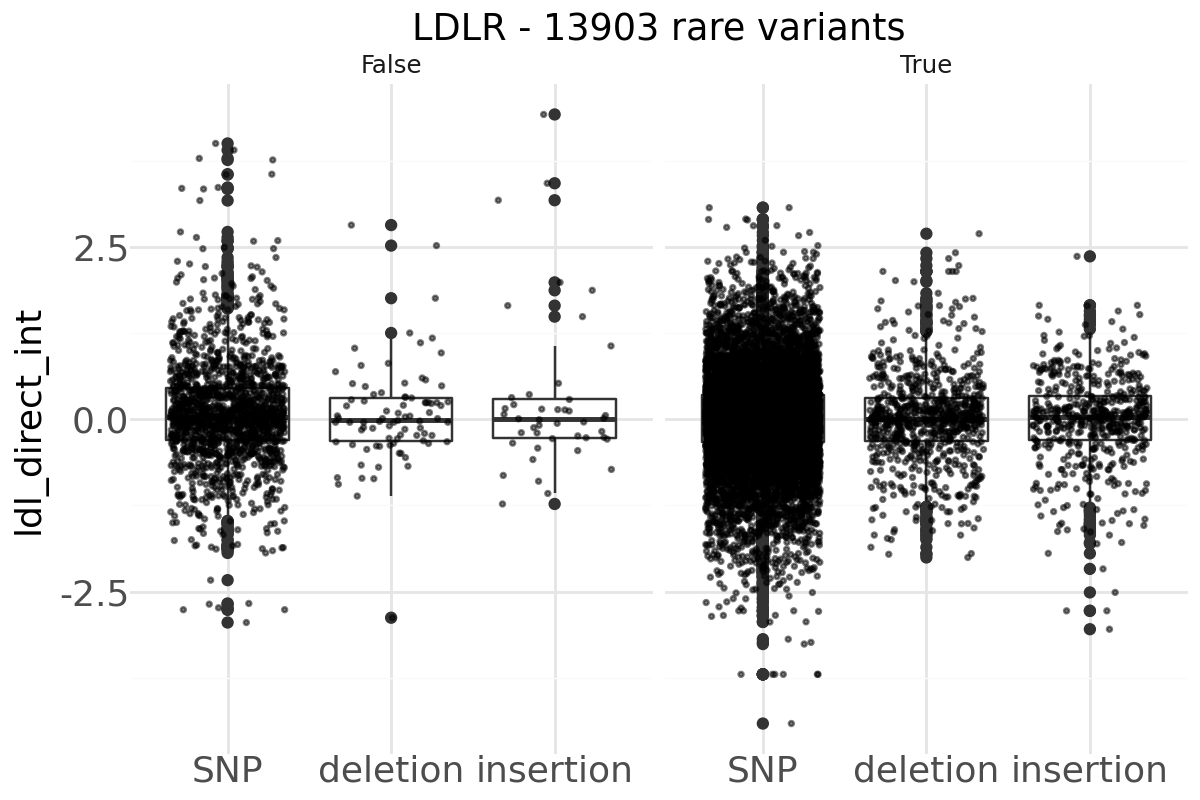

In [ ]:
(
    ggplot(pg_df, aes(x='indel_type', y='mean_pheno_value')) +
    geom_boxplot(width=0.75) +
    geom_jitter(alpha=0.5, width=0.35, size=0.5, height=0) +
    theme_minimal() +
    labs(
        x='',
        y=phenotype,
        title=f"{gene_name} - {pg_df.shape[0]} rare variants"
    ) +
    facet_wrap("~vep_gencode_non_coding") +
    theme(
        figure_size=(6, 4),
        legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
    )
)

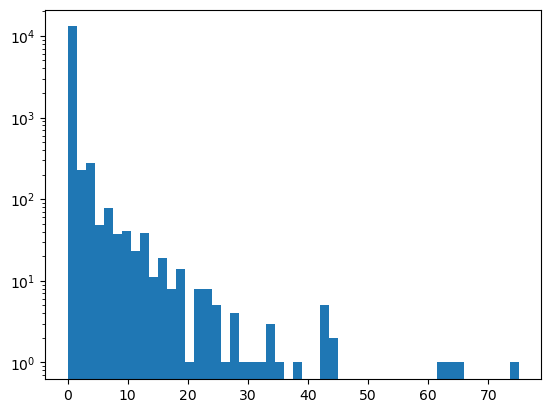

In [46]:
plt.hist(pg_df['indel_length'], log=True, bins=50)
plt.show()

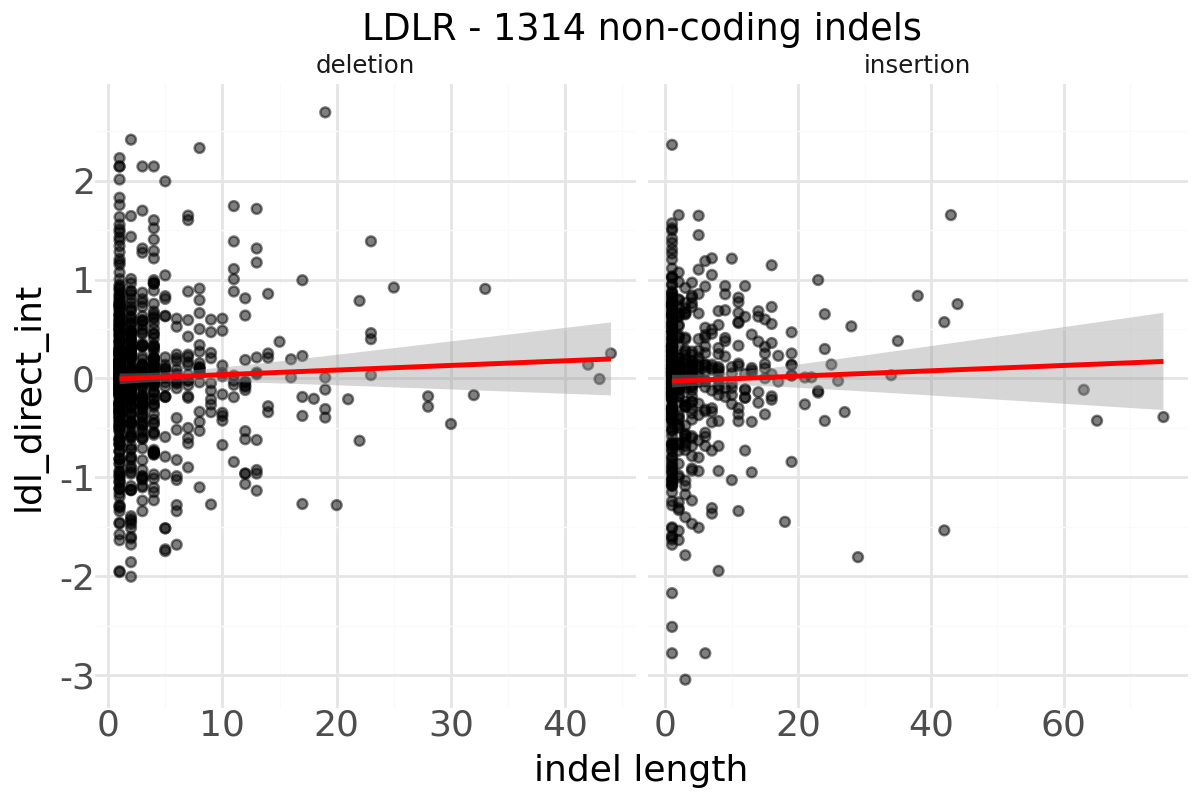

In [53]:
indel_nc_df = pg_df.filter(
    (pl.col('indel_length') > 0) &
    (pl.col('vep_gencode_non_coding')==True)
)

(
    ggplot(indel_nc_df, aes(x='indel_length', y='mean_pheno_value')) +
    geom_point(alpha=0.5) +
    theme_minimal() +
    labs(
        x='indel length',
        y=phenotype,
        title=f"{gene_name} - {indel_nc_df.shape[0]} non-coding indels"
    ) +
    geom_smooth(method='lm', se=True, color='red') +
    facet_wrap("~indel_type", scales='free_x') +
    theme(
        figure_size=(6, 4),
        legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
    )
)

## Plot correlations across associations

In [5]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [ ]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    
    # B. Join the other two dataframes
    .join(
        anno.lazy(),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')